# Plant Disease Classification — ResNet50 Transfer Learning (Colab T4)

Two-phase transfer learning on the Kaggle *New Plant Diseases Dataset (Augmented)*.

**All improvements applied:**
- Seed control for reproducibility
- `preprocess_input` — correct ResNet50 ImageNet normalization
- Mixed precision `float16` — ~2x speed on T4
- Augmentation tuned for PlantVillage (controlled conditions)
- Phase 1 LR = `1e-4`, Phase 2 LR = `1e-5` (both correct)
- Label smoothing `0.1`
- Class weights
- Top-3 accuracy metric
- Grad-CAM with robust layer lookup + float32 cast
- Training logs saved to JSON
- TTA (Test-Time Augmentation)
- Google Drive backup in separate optional cell

**How to run:** Open in Google Colab → `Runtime` → `Change runtime type` → **T4 GPU**.
Upload your `kaggle.json` to the Colab session files panel, then `Run all`.

## 0. Kaggle Authentication

Upload your `kaggle.json` API token (left sidebar → Files → upload) **before** running this cell.
Get it from [kaggle.com/settings](https://www.kaggle.com/settings) → **API** → **Create New Token**.

In [ ]:
!pip install kagglehub -q

import kagglehub
kagglehub.login()  # interactive prompt: paste your Kaggle username + API key

print("Kaggle setup done!")

Kaggle setup done!
Kaggle credentials set.
Kaggle credentials successfully validated.


## 1. Setup — Imports, Seed Control & Mixed Precision

- **Seed control:** fixes `random`, `numpy`, and `tensorflow` seeds so results are reproducible across runs
- **Mixed precision:** `float16` compute on T4 GPU, `float32` weights — ~2x faster training

In [ ]:
!pip install -q kagglehub

import kagglehub
import os, glob, shutil, random, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# FIX: Seed control — ensures reproducible results across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'Seeds fixed: {SEED}')

# Mixed precision: float16 compute, float32 weights
mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', mixed_precision.global_policy())
print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

Seeds fixed: 42
Mixed precision policy: <DTypePolicy "mixed_float16">
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download Dataset

In [ ]:
path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
print('Dataset path:', path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Dataset path: /kaggle/input/new-plant-diseases-dataset
new-plant-diseases-dataset/
  New Plant Diseases Dataset(Augmented)/
    New Plant Diseases Dataset(Augmented)/
  new plant diseases dataset(augmented)/
    New Plant Diseases Dataset(Augmented)/
  test/
    test/


## 3. Explore — Class Distribution

`glob` recursive lookup auto-finds `train`/`valid` folders regardless of nesting — avoids FileNotFoundError.

TRAIN_DIR: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
VALID_DIR: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy'

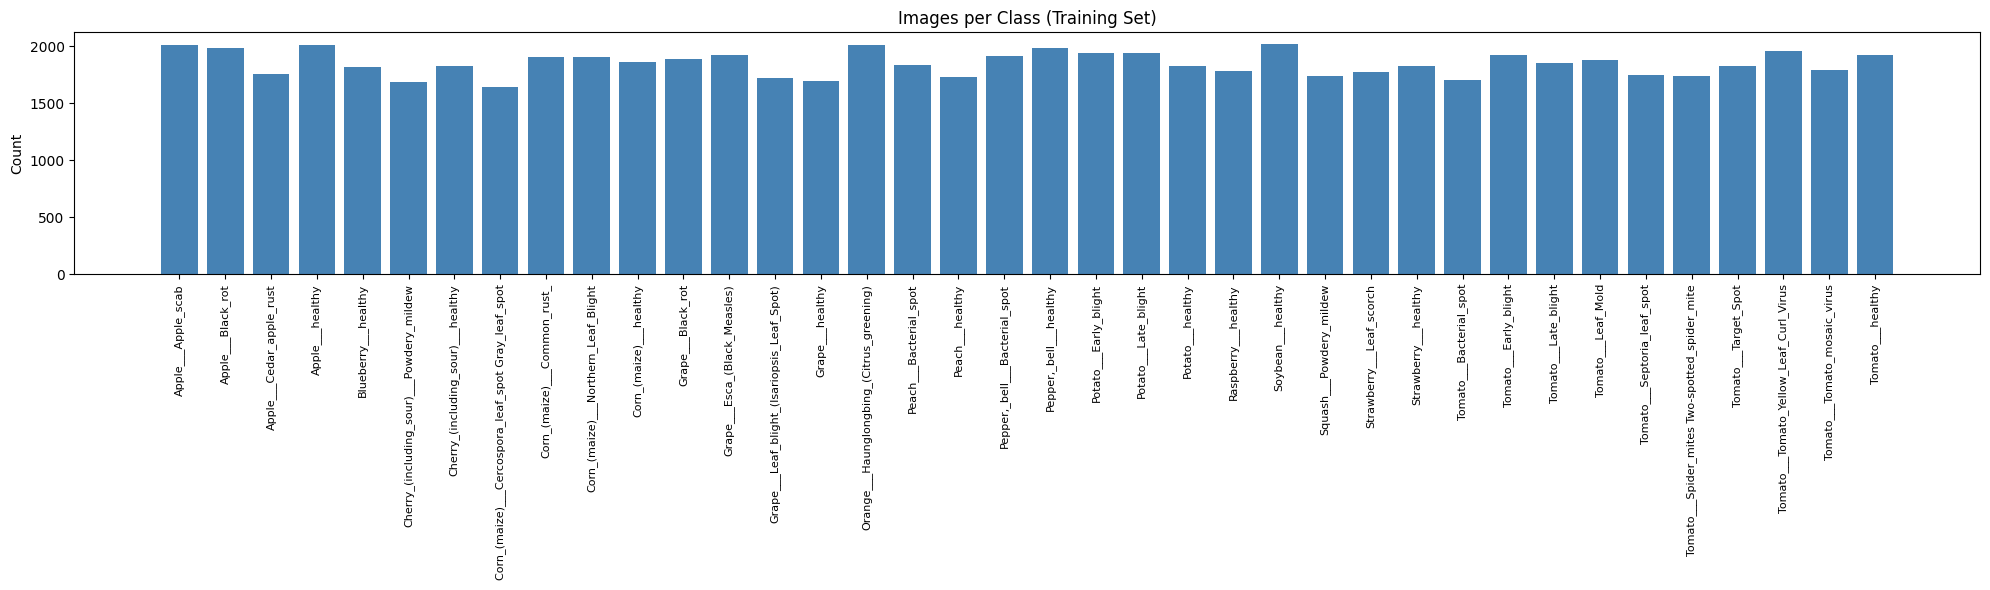


Total training images: 70295


In [ ]:
TRAIN_DIR = glob.glob(os.path.join(path, '**', 'train'), recursive=True)[0]
VALID_DIR = glob.glob(os.path.join(path, '**', 'valid'), recursive=True)[0]
print('TRAIN_DIR:', TRAIN_DIR)
print('VALID_DIR:', VALID_DIR)

class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)
print(f'Number of classes: {num_classes}')
print(f'Classes: {class_names}')

class_counts = {}
for cls in class_names:
    cls_path = os.path.join(TRAIN_DIR, cls)
    class_counts[cls] = len(os.listdir(cls_path))

plt.figure(figsize=(20, 6))
plt.bar(range(num_classes), class_counts.values(), color='steelblue')
plt.xticks(range(num_classes), class_names, rotation=90, fontsize=8)
plt.title('Images per Class (Training Set)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'\nTotal training images: {sum(class_counts.values())}')

## 4. Explore — Sample Images

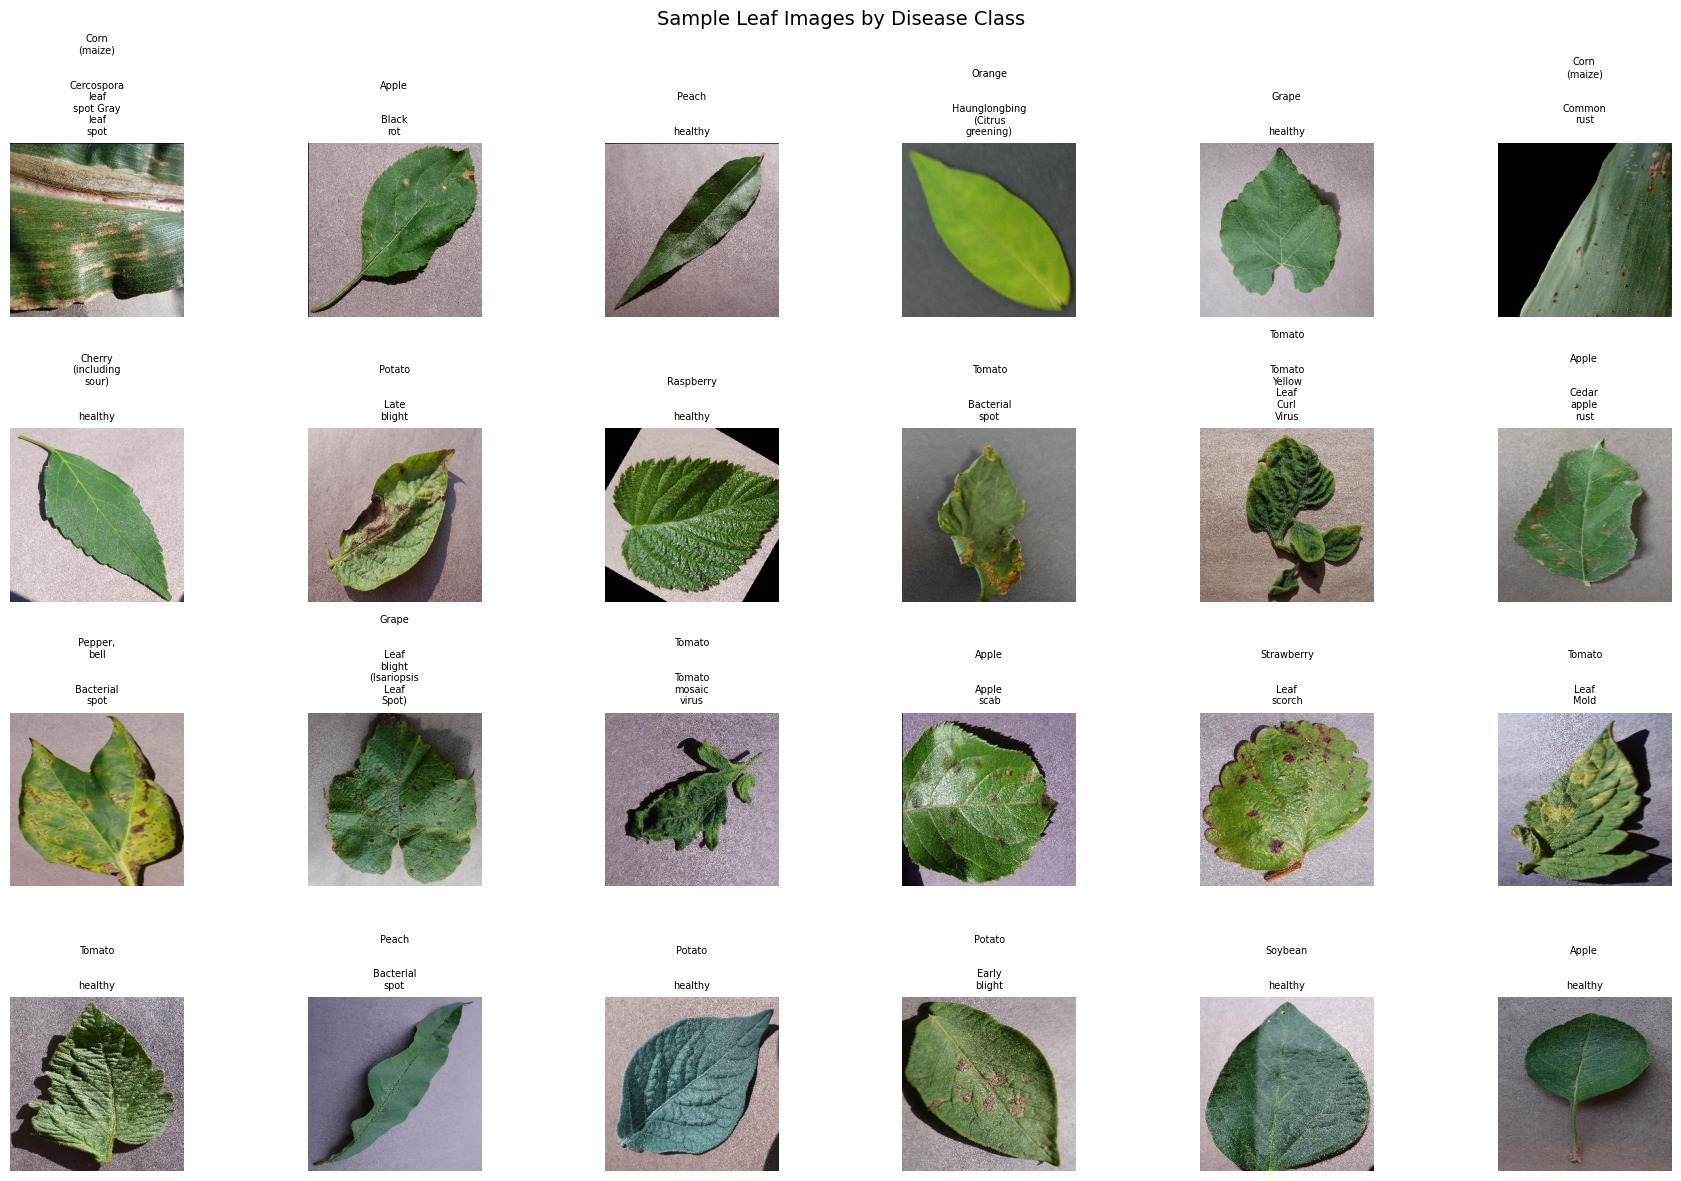

In [ ]:
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

sample_classes = random.sample(class_names, min(24, num_classes))

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls.replace('_', '\n'), fontsize=7)
    axes[i].axis('off')

plt.suptitle('Sample Leaf Images by Disease Class', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Preprocessing & Augmentation

**FIX — Augmentation rolled back to PlantVillage benchmarks:**
PlantVillage is photographed in controlled conditions (centered leaf, uniform background).
Published benchmarks (Mohanty et al., Too & Yujian) use mild augmentation — aggressive settings hurt accuracy.
- `rotation_range=20` (was 40)
- `*_shift=0.2`, `zoom=0.2`, `shear=0.2` (all reduced from 0.3)
- `vertical_flip=False` (removed — not realistic for this dataset)
- `brightness_range=[0.8, 1.2]` (narrowed from [0.7, 1.3])
- `channel_shift_range=10` (kept at 10)

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Augmentation tuned for PlantVillage controlled conditions
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # correct ResNet50 normalization
    rotation_range=20,           # rolled back from 40 — matches PlantVillage benchmarks
    width_shift_range=0.2,       # rolled back from 0.3
    height_shift_range=0.2,      # rolled back from 0.3
    shear_range=0.2,             # rolled back from 0.3
    zoom_range=0.2,              # rolled back from 0.3
    horizontal_flip=True,
    vertical_flip=False,         # removed — not realistic for PlantVillage
    brightness_range=[0.8, 1.2], # narrowed from [0.7, 1.3]
    channel_shift_range=10,      # kept at 10
    fill_mode='nearest'
)

# Validation — preprocessing only, no augmentation
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # MUST be False for correct label matching
)

print(f'Training batches:   {len(train_generator)}')
print(f'Validation batches: {len(val_generator)}')
print(f'Classes detected:   {train_generator.num_classes}')

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Training batches:   2197
Validation batches: 550
Classes detected:   38


## 7. Build Model — ResNet50 Frozen Base (Phase 1)

- `dtype='float32'` on output layer — required for stability with `mixed_float16`
- Label smoothing `0.1` — prevents overconfident predictions
- Phase 1 LR = `1e-4` — standard for head-only training, smoother than `1e-3`
- Top-3 accuracy metric added

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# Functional API for better control
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # training=False keeps BN frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
# dtype='float32' required for numerical stability with mixed_float16
outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # 1e-4 for head-only training
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')
    ]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,786,086 (94.55 MB)

 Trainable params: 1,194,278 (4.56 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 8. Compute Class Weights

In [ ]:
# PlantVillage is deliberately balanced (~2000 imgs/class)
# Weights will be ~1.0 for all classes, but kept for correctness
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

print('Class weights computed:')
for cls, w in zip(class_names, class_weights):
    print(f'  {cls}: {w:.4f}')

Class weights computed:
  Apple___Apple_scab: 0.9176
  Apple___Black_rot: 0.9310
  Apple___Cedar_apple_rust: 1.0511
  Apple___healthy: 0.9212
  Blueberry___healthy: 1.0187
  Cherry_(including_sour)___Powdery_mildew: 1.0991
  Cherry_(including_sour)___healthy: 1.0131
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1.1266
  Corn_(maize)___Common_rust_: 0.9700
  Corn_(maize)___Northern_Leaf_Blight: 0.9695
  Corn_(maize)___healthy: 0.9951
  Grape___Black_rot: 0.9798
  Grape___Esca_(Black_Measles): 0.9635
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1.0743
  Grape___healthy: 1.0933
  Orange___Haunglongbing_(Citrus_greening): 0.9203
  Peach___Bacterial_spot: 1.0065
  Peach___healthy: 1.0705
  Pepper,_bell___Bacterial_spot: 0.9670
  Pepper,_bell___healthy: 0.9305
  Potato___Early_blight: 0.9540
  Potato___Late_blight: 0.9540
  Potato___healthy: 1.0142
  Raspberry___healthy: 1.0387
  Soybean___healthy: 0.9149
  Squash___Powdery_mildew: 1.0656
  Strawberry___Leaf_scorch: 1.0428
  Strawbe

## 9. Phase 1 — Train Frozen Base

In [ ]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print('=== PHASE 1: Training with frozen base (LR=1e-4) ===')
history1 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1
)

=== PHASE 1: Training with frozen base (LR=1e-4) ===
Epoch 1/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1319s 591ms/step - accuracy: 0.6582 - loss: 1.7812 - top_3_accuracy: 0.8280 - val_accuracy: 0.9293 - val_loss: 1.0411 - val_top_3_accuracy: 0.9894 - learning_rate: 1.0000e-04
Epoch 2/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1117s 508ms/step - accuracy: 0.8591 - loss: 1.2244 - top_3_accuracy: 0.9657 - val_accuracy: 0.9488 - val_loss: 0.9588 - val_top_3_accuracy: 0.9929 - learning_rate: 1.0000e-04
Epoch 3/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1155s 526ms/step - accuracy: 0.8984 - loss: 1.1230 - top_3_accuracy: 0.9788 - val_accuracy: 0.9572 - val_loss: 0.9173 - val_top_3_accuracy: 0.9955 - learning_rate: 1.0000e-04


## 10. Plot Phase 1 Results

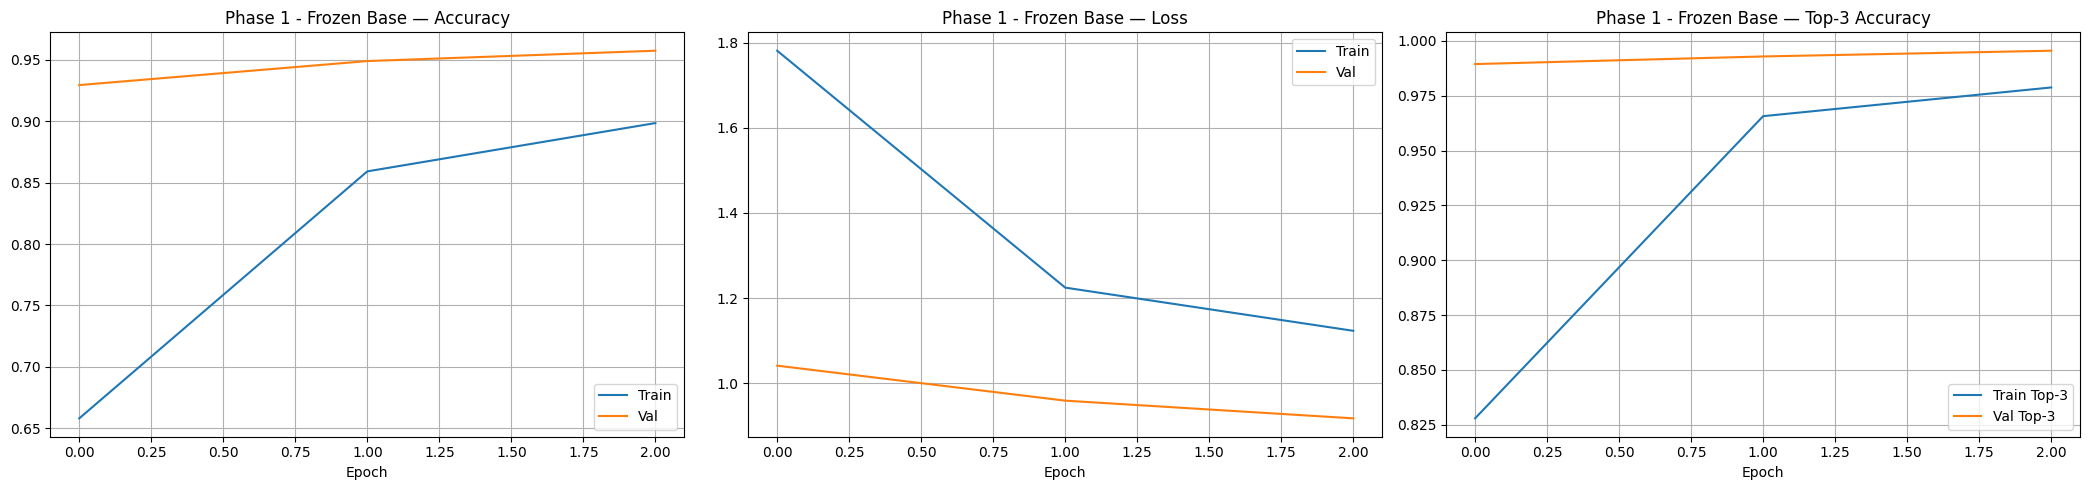

In [ ]:
def plot_history(history, title='Training'):
    has_top3 = 'top_3_accuracy' in history.history
    ncols = 3 if has_top3 else 2
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))

    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    if has_top3:
        axes[2].plot(history.history['top_3_accuracy'], label='Train Top-3')
        axes[2].plot(history.history['val_top_3_accuracy'], label='Val Top-3')
        axes[2].set_title(f'{title} — Top-3 Accuracy')
        axes[2].set_xlabel('Epoch')
        axes[2].legend()
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history1, 'Phase 1 - Frozen Base')

## 11. Phase 2 — Unfreeze & Fine-tune

**FIX — Phase 2 LR corrected to `1e-5` (was `5e-6`):**
With 50 unfrozen layers and mixed precision gradient noise, `5e-6` was too low
to meaningfully update weights in 25 epochs — fine-tuning was essentially a no-op.
`1e-5` is the standard recommendation for ResNet50 fine-tuning.
`min_lr` also corrected to `1e-7` (was `1e-8` — unreachably low).

Trainable layers: 9
=== PHASE 2: Fine-tuning unfrozen layers (LR=1e-5) ===
Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1210s 534ms/step - accuracy: 0.9192 - loss: 1.0716 - top_3_accuracy: 0.9854 - val_accuracy: 0.9751 - val_loss: 0.8684 - val_top_3_accuracy: 0.9979 - learning_rate: 1.0000e-05
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1132s 515ms/step - accuracy: 0.9520 - loss: 0.9819 - top_3_accuracy: 0.9931 - val_accuracy: 0.9821 - val_loss: 0.8264 - val_top_3_accuracy: 0.9987 - learning_rate: 1.0000e-05
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1159s 528ms/step - accuracy: 0.9663 - loss: 0.9333 - top_3_accuracy: 0.9961 - val_accuracy: 0.9875 - val_loss: 0.7963 - val_top_3_accuracy: 0.9994 - learning_rate: 1.0000e-05
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1145s 521ms/step - accuracy: 0.9759 - loss: 0.8959 - top_3_accuracy: 0.9976 - val_accuracy: 0.9879 - val_loss: 0.7797 - val_top_3_accuracy: 0.9995 - learning_rate: 1.0000e-05
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1152s 525ms/step - a

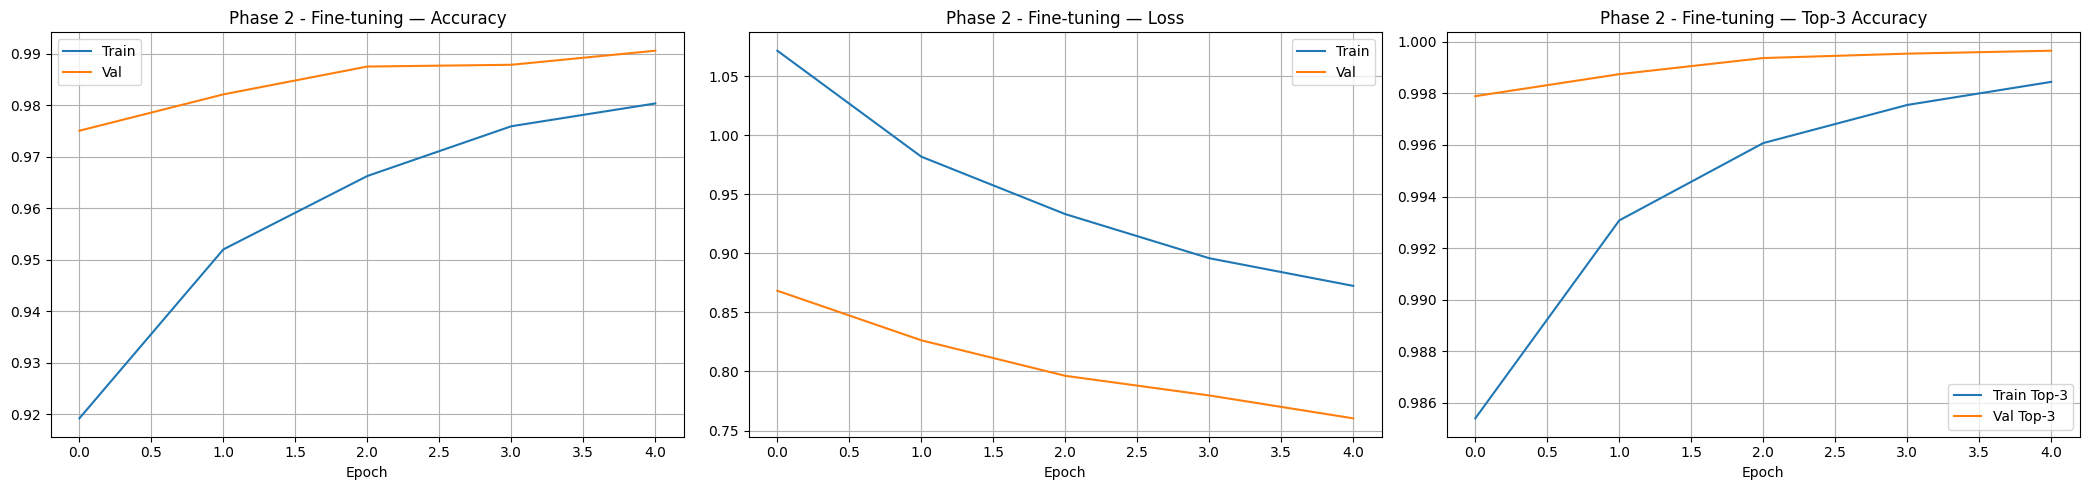

In [ ]:
# Unfreeze last 50 layers of ResNet50
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# FIX: Phase 2 LR = 1e-5 (was 5e-6 — too low to update 50 unfrozen layers)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')
    ]
)

print(f'Trainable layers: {sum(1 for l in model.layers if l.trainable)}')

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_model_final.keras', monitor='val_accuracy', save_best_only=True),
    # FIX: min_lr=1e-7 (was 1e-8 — unreachable with factor=0.3 from starting 1e-5)
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7)
]

print('=== PHASE 2: Fine-tuning unfrozen layers (LR=1e-5) ===')
history2 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2
)

plot_history(history2, 'Phase 2 - Fine-tuning')

## 12. Evaluation — Classification Report & Confusion Matrix

Found 17572 images belonging to 38 classes.
550/550 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step

=== Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.99      1.00       504
                                 Apple___Black_rot       0.99      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       0.99      1.00      1.00       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.96      0.96       410
                       Corn_(maize)___Common_rust_   

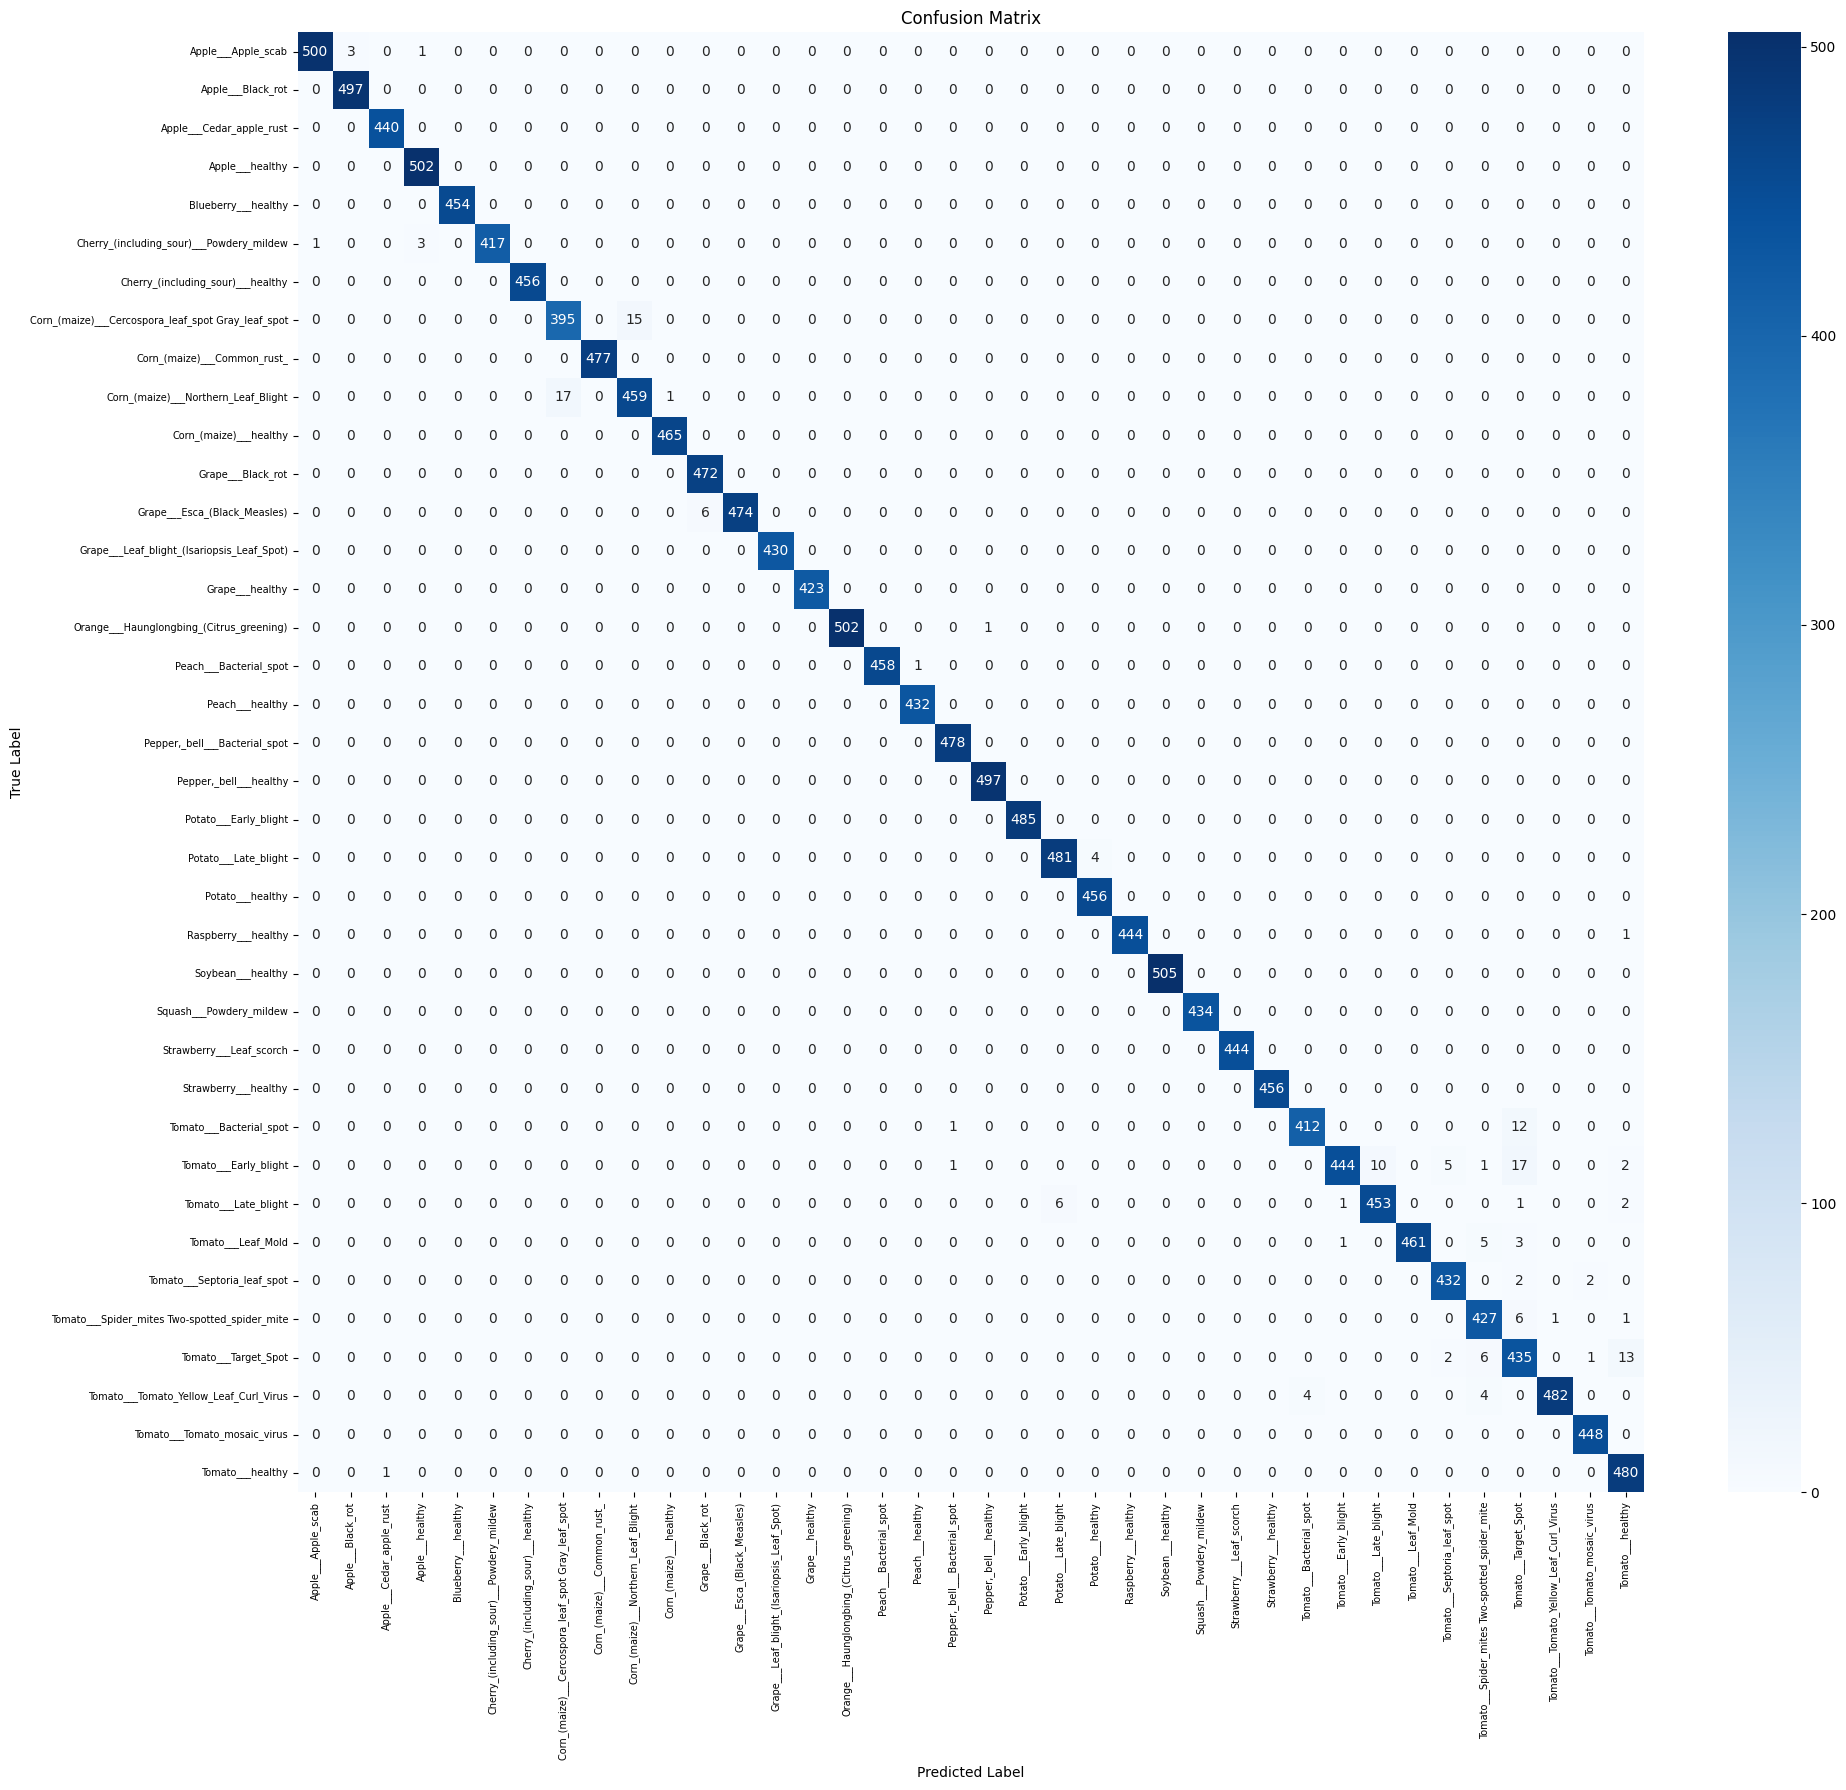


Final Test Accuracy: 99.06%


In [ ]:
# Reload best model
model = tf.keras.models.load_model('best_model_final.keras')

# Fresh val generator — avoids any stale state after long training
val_datagen_eval = ImageDataGenerator(preprocessing_function=preprocess_input)
val_generator_eval = val_datagen_eval.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # CRITICAL — must be False for correct label alignment
)

y_pred_probs = model.predict(val_generator_eval, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator_eval.classes

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f'\nFinal Test Accuracy: {accuracy*100:.2f}%')

## 13. Test-Time Augmentation (TTA)

Averages predictions over 5 augmented passes — typically +1–2% accuracy with zero extra training.

In [ ]:
print('=== Test-Time Augmentation (TTA) — 5 passes ===')

tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

all_preds = []
N_TTA = 5

for i in range(N_TTA):
    print(f'  Pass {i+1}/{N_TTA}...')
    tta_gen = tta_datagen.flow_from_directory(
        VALID_DIR,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False  # CRITICAL — consistent order across passes
    )
    all_preds.append(model.predict(tta_gen, verbose=0))

tta_pred_probs = np.mean(all_preds, axis=0)
tta_pred = np.argmax(tta_pred_probs, axis=1)
y_true_tta = val_generator_eval.classes

tta_accuracy = np.sum(tta_pred == y_true_tta) / len(y_true_tta)
print(f'\nAccuracy without TTA: {accuracy*100:.2f}%')
print(f'Accuracy with TTA:    {tta_accuracy*100:.2f}%')
print(f'TTA Gain:             +{(tta_accuracy - accuracy)*100:.2f}%')

print('\n=== TTA Classification Report ===')
print(classification_report(y_true_tta, tta_pred, target_names=class_names))

=== Test-Time Augmentation (TTA) — 5 passes ===
  Pass 1/5...
Found 17572 images belonging to 38 classes.
  Pass 2/5...
Found 17572 images belonging to 38 classes.
  Pass 3/5...
Found 17572 images belonging to 38 classes.
  Pass 4/5...
Found 17572 images belonging to 38 classes.
  Pass 5/5...
Found 17572 images belonging to 38 classes.

Accuracy without TTA: 99.06%
Accuracy with TTA:    99.44%
TTA Gain:             +0.38%

=== TTA Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       504
                                 Apple___Black_rot       1.00      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       1.00      1.00      1.00       502
                               Blueberry___healthy       1.00      1.00      1

## 13.5. Final Metrics Summary

Single-block summary of all key metrics for the report/paper: accuracy, precision, recall, F1 (macro and weighted), plus best val accuracy from each training phase.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print('=' * 60)
print('FINAL MODEL SUMMARY')
print('=' * 60)

best_p1_acc = max(history1.history['val_accuracy'])
best_p2_acc = max(history2.history['val_accuracy'])
print(f'\nPhase 1 (frozen base) best val accuracy: {best_p1_acc*100:.2f}%')
print(f'Phase 2 (fine-tuned)  best val accuracy: {best_p2_acc*100:.2f}%')

print('\n--- Final Evaluation (no TTA) ---')
print(f'Accuracy:             {accuracy_score(y_true, y_pred)*100:.2f}%')
print(f'Precision (macro):    {precision_score(y_true, y_pred, average="macro", zero_division=0)*100:.2f}%')
print(f'Recall    (macro):    {recall_score(y_true, y_pred, average="macro", zero_division=0)*100:.2f}%')
print(f'F1-score  (macro):    {f1_score(y_true, y_pred, average="macro", zero_division=0)*100:.2f}%')
print(f'Precision (weighted): {precision_score(y_true, y_pred, average="weighted", zero_division=0)*100:.2f}%')
print(f'Recall    (weighted): {recall_score(y_true, y_pred, average="weighted", zero_division=0)*100:.2f}%')
print(f'F1-score  (weighted): {f1_score(y_true, y_pred, average="weighted", zero_division=0)*100:.2f}%')

print('\n--- Final Evaluation (with TTA) ---')
print(f'Accuracy:             {accuracy_score(y_true_tta, tta_pred)*100:.2f}%')
print(f'Precision (macro):    {precision_score(y_true_tta, tta_pred, average="macro", zero_division=0)*100:.2f}%')
print(f'Recall    (macro):    {recall_score(y_true_tta, tta_pred, average="macro", zero_division=0)*100:.2f}%')
print(f'F1-score  (macro):    {f1_score(y_true_tta, tta_pred, average="macro", zero_division=0)*100:.2f}%')
print(f'Precision (weighted): {precision_score(y_true_tta, tta_pred, average="weighted", zero_division=0)*100:.2f}%')
print(f'Recall    (weighted): {recall_score(y_true_tta, tta_pred, average="weighted", zero_division=0)*100:.2f}%')
print(f'F1-score  (weighted): {f1_score(y_true_tta, tta_pred, average="weighted", zero_division=0)*100:.2f}%')

print('\n' + '=' * 60)

FINAL MODEL SUMMARY

Phase 1 (frozen base) best val accuracy: 95.72%
Phase 2 (fine-tuned)  best val accuracy: 99.06%

--- Final Evaluation (no TTA) ---
Accuracy:             99.06%
Precision (macro):    99.06%
Recall    (macro):    99.05%
F1-score  (macro):    99.05%
Precision (weighted): 99.08%
Recall    (weighted): 99.06%
F1-score  (weighted): 99.06%

--- Final Evaluation (with TTA) ---
Accuracy:             99.44%
Precision (macro):    99.43%
Recall    (macro):    99.43%
F1-score  (macro):    99.43%
Precision (weighted): 99.45%
Recall    (weighted): 99.44%
F1-score  (weighted): 99.44%



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 14. Grad-CAM — Visual Explanation

Shows **which part of the leaf** the model focused on when making its prediction.

**FIX — Robust layer lookup:**
- Finds the ResNet50 submodel by type (not hardcoded name) — survives re-runs and `load_model`
- Casts tensors to `float32` before matmul — prevents silent precision loss with `mixed_float16`

True class: Corn_(maize)___healthy


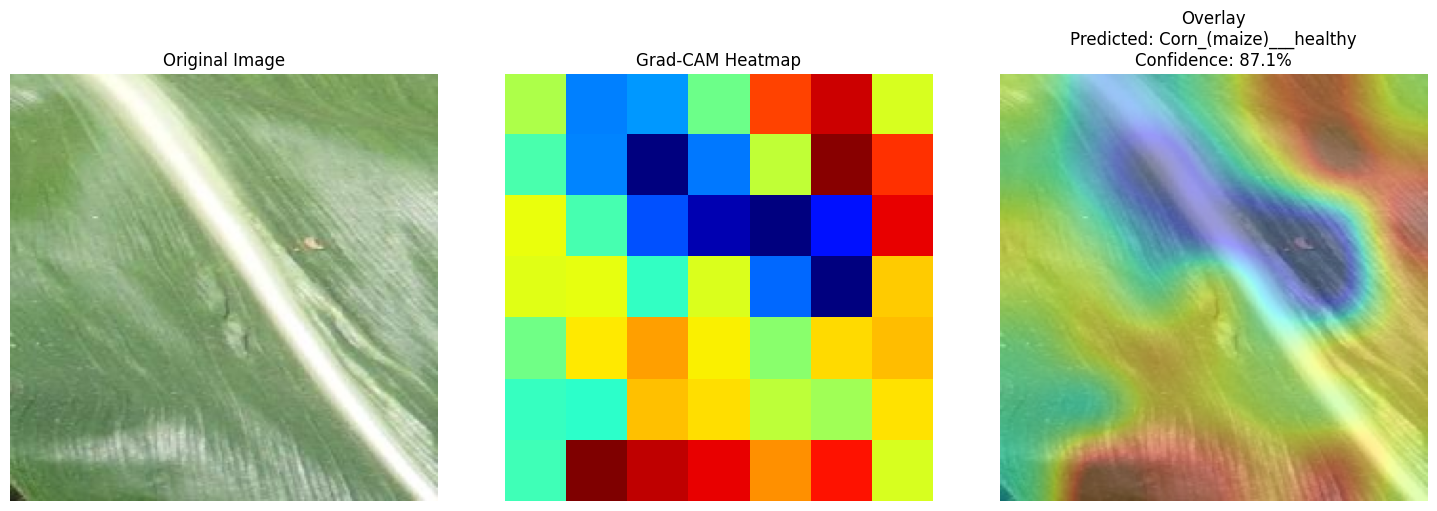

Predicted: Corn_(maize)___healthy (87.1%)


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    """
    Grad-CAM heatmap for the predicted class.
    Keras 3 / TF 2.16+ compatible: splits the network into two sub-models because
    you can no longer mix tensors from a nested submodel's graph with the outer model.
    """
    # Find the ResNet50 submodel by type (immune to Keras renaming)
    resnet_submodel = next(l for l in model.layers if isinstance(l, tf.keras.Model))
    last_conv_layer = resnet_submodel.get_layer(last_conv_layer_name)

    # Sub-model A: image -> last conv activations (lives entirely inside ResNet)
    conv_model = tf.keras.Model(resnet_submodel.input, last_conv_layer.output)

    # Sub-model B: replay the head on a fresh input of the same shape
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Skip layers[0]=InputLayer and layers[1]=ResNet50; replay the rest of the head
    for layer in model.layers[2:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        conv_outputs = tf.cast(conv_outputs, tf.float32)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        predictions = tf.cast(predictions, tf.float32)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    grads = tf.cast(grads, tf.float32)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), float(tf.reduce_max(predictions))


def show_gradcam(img_path, model, class_names):
    """Loads an image, runs Grad-CAM, and displays original + heatmap + overlay."""
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_preprocessed = preprocess_input(img_array.copy())
    img_preprocessed = np.expand_dims(img_preprocessed, axis=0)

    heatmap, pred_index, confidence = make_gradcam_heatmap(img_preprocessed, model)
    predicted_class = class_names[pred_index]

    # Resize heatmap and apply colormap
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_img = Image.fromarray(heatmap_resized).resize((224, 224))
    heatmap_colored = plt.get_cmap('jet')(np.array(heatmap_img) / 255.0)[:, :, :3]
    heatmap_colored = np.uint8(heatmap_colored * 255)

    # Overlay: 60% original + 40% heatmap
    original = np.array(img)
    overlay = np.uint8(0.6 * original + 0.4 * heatmap_colored)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\nPredicted: {predicted_class}\nConfidence: {confidence*100:.1f}%')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Predicted: {predicted_class} ({confidence*100:.1f}%)')


# Demo: run Grad-CAM on a random validation image
random_class = random.choice(class_names)
random_class_path = os.path.join(VALID_DIR, random_class)
random_img_path = os.path.join(random_class_path, random.choice(os.listdir(random_class_path)))

print(f'True class: {random_class}')
show_gradcam(random_img_path, model, class_names)

## 15. Save Training Logs & Model

In [ ]:
# Save combined training history to JSON — useful for paper/report
combined_history = {
    'phase1': {k: [float(v) for v in vals] for k, vals in history1.history.items()},
    'phase2': {k: [float(v) for v in vals] for k, vals in history2.history.items()},
    'final_accuracy': float(accuracy),
    'tta_accuracy': float(tta_accuracy)
}

with open('training_history.json', 'w') as f:
    json.dump(combined_history, f, indent=2)
print('Training history saved → training_history.json')

# Save final model
model.save('plant_disease_model.keras')
print('Model saved → plant_disease_model.keras')

Training history saved → training_history.json
Model saved → plant_disease_model.keras


## 16. Google Drive Backup (Optional)

**FIX — Moved to its own cell:** `drive.mount()` requires interactive auth and blocks `Run all`.
Run this cell manually after training completes.

In [ ]:
# Run this cell MANUALLY after training — requires interactive Google auth
from google.colab import drive
drive.mount('/content/drive')

files_to_backup = [
    'best_model_final.keras',
    'best_model_phase1.keras',
    'plant_disease_model.keras',
    'training_history.json'
]

for f in files_to_backup:
    if os.path.exists(f):
        shutil.copy(f, f'/content/drive/MyDrive/{f}')
        print(f'Backed up: {f}')
    else:
        print(f'Skipped (not found): {f}')

print('\nAll available files backed up to Google Drive!')

Mounted at /content/drive
Backed up: best_model_final.keras
Backed up: best_model_phase1.keras
Backed up: plant_disease_model.keras
Backed up: training_history.json

All available files backed up to Google Drive!


## 17. Predict Single Image

In [ ]:
def predict_disease(img_path, model, class_names, show_gradcam_overlay=True):
    """Predicts disease from a leaf image. Shows top-3 predictions and Grad-CAM overlay."""
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_preprocessed = preprocess_input(img_array.copy())
    img_preprocessed = np.expand_dims(img_preprocessed, axis=0)

    predictions = model.predict(img_preprocessed, verbose=0)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Top-3 predictions
    top3_idx = np.argsort(predictions[0])[::-1][:3]
    print('Top 3 Predictions:')
    for i, idx in enumerate(top3_idx):
        print(f'  {i+1}. {class_names[idx]}: {predictions[0][idx]*100:.1f}%')

    if show_gradcam_overlay:
        show_gradcam(img_path, model, class_names)
    else:
        plt.imshow(img)
        plt.title(f'Predicted: {predicted_class}\nConfidence: {confidence:.1f}%')
        plt.axis('off')
        plt.show()

    return predicted_class, confidence


# Example — upload a leaf image to Colab first, then run:
predict_disease('/content/my_leaf.png', model, class_names)

FileNotFoundError: [Errno 2] No such file or directory: '/content/my_leaf.png'

## 19. Quick Predict from Upload

One-click prediction: run this cell, click the **Choose Files** button, pick a leaf image, and it will predict + show the Grad-CAM overlay automatically. Supports multiple files at once (Ctrl/Cmd-click to select several).

Saving image.6png.png to image.6png.png

=== Predicting: image.6png.png ===
Top 3 Predictions:
  1. Corn_(maize)___Common_rust_: 18.1%
  2. Tomato___Tomato_Yellow_Leaf_Curl_Virus: 7.3%
  3. Cherry_(including_sour)___Powdery_mildew: 5.6%


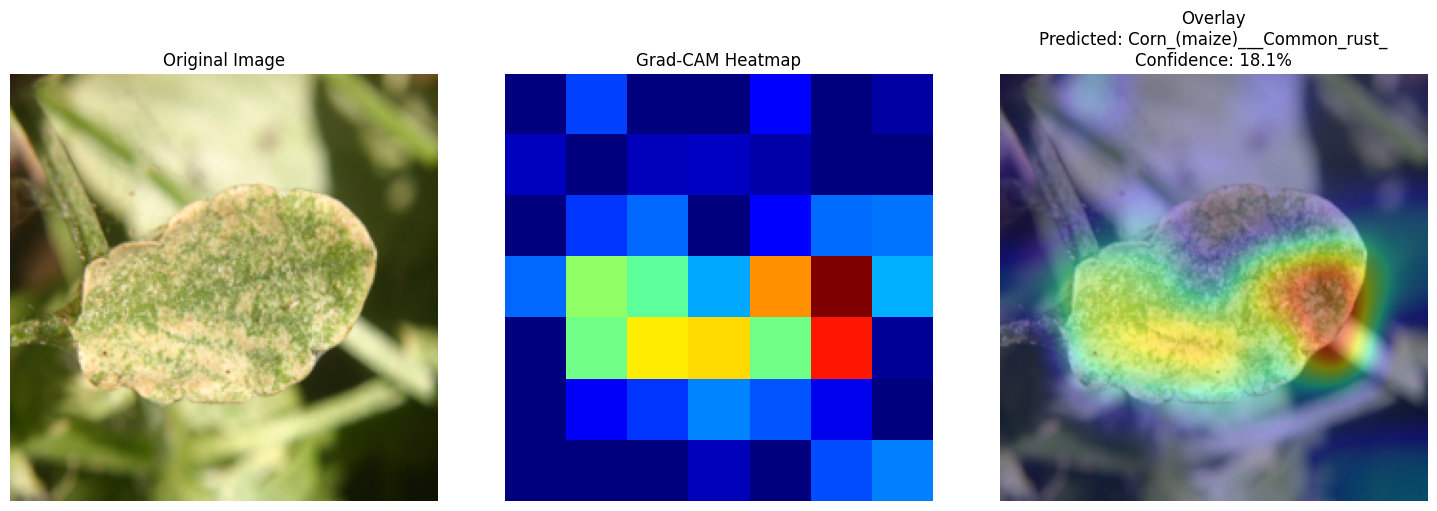

Predicted: Corn_(maize)___Common_rust_ (18.1%)


In [ ]:
from google.colab import files

uploaded = files.upload()  # opens file picker — choose one or more leaf images

for filename in uploaded.keys():
    print(f'\n=== Predicting: {filename} ===')
    predict_disease(f'/content/{filename}', model, class_names)